# 01 — Simulator development sandbox

Iterate on the **physics-based machine simulator** here, in isolation from
Eventstream / Fabric / GPU training.

Workflow:

1. Define the machine's **operating-state FSM** (`OFF`, `STARTUP`, `IDLE`, `PRODUCTION_LIGHT/HEAVY`, `RAMP_UP/DOWN`, `SHUTDOWN`).
2. Define a **physical state** (load, motor temp, bearing temp) with first-order dynamics.
3. **Derive** the 8 sensor channels from physical state (with coupling).
4. Run a long simulation, collect into a DataFrame.
5. Plot: state timeline, sensor traces, sensor correlations.
6. Tune coefficients until the traces "look real", then port back to `simulator-local/simulate_machines.py`.

> Reference plan: `.copilot/PLAN.md` Phase 1.


## 1. Setup

In [1]:
from __future__ import annotations

import math
import random
from dataclasses import dataclass, field
from enum import Enum

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reproducibility while we tune
RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 3)
plt.rcParams["axes.grid"] = True

## 2. Operating-state FSM

States and how they transition. Each state has:
- a **target load** (0..1) the machine asks the actuator to reach,
- a **dwell distribution** (how long it stays before considering a transition),
- a **next-state distribution** (what comes next, with probabilities).

`RAMP_*` are short transitional states between two regimes — the physical load smoothly walks toward the new setpoint.

In [2]:
class State(str, Enum):
    OFF              = "OFF"
    STARTUP          = "STARTUP"
    IDLE             = "IDLE"
    PRODUCTION_LIGHT = "PRODUCTION_LIGHT"
    PRODUCTION_HEAVY = "PRODUCTION_HEAVY"
    RAMP_UP          = "RAMP_UP"
    RAMP_DOWN        = "RAMP_DOWN"
    SHUTDOWN         = "SHUTDOWN"


@dataclass
class StateSpec:
    target_load: float                       # 0..1
    dwell_s: tuple[float, float]             # (min, max) seconds in this state
    transitions: list[tuple[State, float]]   # (next_state, weight)


# Tunable transition table. Weights are renormalized on use.
STATE_SPECS: dict[State, StateSpec] = {
    State.OFF: StateSpec(
        target_load=0.0,
        dwell_s=(120, 600),                  # 2..10 min off (short for demo)
        transitions=[(State.STARTUP, 1.0)],
    ),
    State.STARTUP: StateSpec(
        target_load=0.10,
        dwell_s=(15, 30),
        transitions=[(State.IDLE, 1.0)],
    ),
    State.IDLE: StateSpec(
        target_load=0.10,
        dwell_s=(60, 300),
        transitions=[
            (State.RAMP_UP,  0.7),
            (State.SHUTDOWN, 0.1),
            (State.IDLE,     0.2),
        ],
    ),
    State.RAMP_UP: StateSpec(
        target_load=0.5,
        dwell_s=(10, 30),
        transitions=[
            (State.PRODUCTION_LIGHT, 0.5),
            (State.PRODUCTION_HEAVY, 0.5),
        ],
    ),
    State.PRODUCTION_LIGHT: StateSpec(
        target_load=0.40,
        dwell_s=(180, 900),
        transitions=[
            (State.RAMP_UP,          0.3),   # to HEAVY
            (State.RAMP_DOWN,        0.4),
            (State.PRODUCTION_LIGHT, 0.3),
        ],
    ),
    State.PRODUCTION_HEAVY: StateSpec(
        target_load=0.85,
        dwell_s=(120, 600),
        transitions=[
            (State.RAMP_DOWN,        0.6),
            (State.PRODUCTION_HEAVY, 0.4),
        ],
    ),
    State.RAMP_DOWN: StateSpec(
        target_load=0.20,
        dwell_s=(10, 30),
        transitions=[
            (State.IDLE,             0.6),
            (State.PRODUCTION_LIGHT, 0.4),
        ],
    ),
    State.SHUTDOWN: StateSpec(
        target_load=0.0,
        dwell_s=(15, 40),
        transitions=[(State.OFF, 1.0)],
    ),
}


def pick_next_state(current: State) -> State:
    spec = STATE_SPECS[current]
    states, weights = zip(*spec.transitions)
    weights = np.array(weights, dtype=float)
    weights = weights / weights.sum()
    # Pick an index, not the enum member directly: numpy would otherwise cast
    # the enum members to fixed-length strings and truncate them.
    idx = int(np.random.choice(len(states), p=weights))
    return states[idx]


def pick_dwell(state: State) -> float:
    lo, hi = STATE_SPECS[state].dwell_s
    return random.uniform(lo, hi)

## 3. Physical state + sensor model

The physical state drives the sensors:

- `load_actual` — first-order lag toward `target_load` of the current state. Time constant differs between ramps (fast) and steady states (slower).
- `T_motor` — first-order with heating ∝ `load²` and cooling toward ambient. Slow time constant (minutes).
- `T_bearing` — slaved to `T_motor` with extra lag.

Sensors are derived from `(load_actual, T_motor, T_bearing)` plus noise.

| Sensor | Driver |
|---|---|
| `spindle_rpm` | nominal RPM, droops slightly under heavy load |
| `current` | a + b·load |
| `power` | current × constant (≈ V·I) |
| `pressure_hydraulic` | c + d·load |
| `vibration_axial` | base + e·load^1.5, jitter grows with load |
| `vibration_radial` | base + f·load^1.2, jitter grows with load |
| `temperature_motor` | the physical state directly |
| `temperature_bearing` | the physical state directly |

All sensors return **0** in `OFF` (the gap-vs-zero decision is left to the publisher; here zeros make plots readable).

In [3]:
@dataclass
class Machine:
    machine_id: str
    nominal_rpm: float = 3000.0
    ambient_c: float = 22.0

    # FSM state
    state: State = State.OFF
    state_elapsed_s: float = 0.0
    state_dwell_s: float = field(default_factory=lambda: pick_dwell(State.OFF))

    # Physical state
    load_actual: float = 0.0
    T_motor: float = 22.0
    T_bearing: float = 22.0

    # Time constants (seconds)
    tau_load_ramp: float = 5.0
    tau_load_steady: float = 30.0
    tau_T_motor: float = 180.0
    tau_T_bearing: float = 300.0

    # Sensor coefficients (tunable)
    k_current_a: float = 1.0
    k_current_b: float = 14.0
    k_power_factor: float = 0.42
    k_pressure_a: float = 80.0
    k_pressure_b: float = 70.0
    k_vib_axial_base: float = 0.10
    k_vib_axial_load: float = 0.25
    k_vib_radial_base: float = 0.15
    k_vib_radial_load: float = 0.35
    k_rpm_droop: float = 0.05

    def step(self, dt: float) -> None:
        self.state_elapsed_s += dt
        if self.state_elapsed_s >= self.state_dwell_s:
            self.state = pick_next_state(self.state)
            self.state_elapsed_s = 0.0
            self.state_dwell_s = pick_dwell(self.state)

        # Load: faster lag during RAMP_*; slower at steady state
        target = STATE_SPECS[self.state].target_load
        tau = self.tau_load_ramp if self.state in (
            State.RAMP_UP, State.RAMP_DOWN, State.STARTUP, State.SHUTDOWN
        ) else self.tau_load_steady
        alpha = 1.0 - math.exp(-dt / tau)
        self.load_actual += alpha * (target - self.load_actual)

        # Thermal: heating proportional to load², cooling toward ambient
        heat_input = 0.0 if self.state == State.OFF else 60.0 * (self.load_actual ** 2)
        T_target_motor = self.ambient_c + heat_input
        a_m = 1.0 - math.exp(-dt / self.tau_T_motor)
        self.T_motor += a_m * (T_target_motor - self.T_motor)

        T_target_bearing = self.ambient_c + 0.85 * (self.T_motor - self.ambient_c)
        a_b = 1.0 - math.exp(-dt / self.tau_T_bearing)
        self.T_bearing += a_b * (T_target_bearing - self.T_bearing)

    def sample(self) -> dict[str, float]:
        if self.state == State.OFF:
            return {k: 0.0 for k in (
                "temperature_motor", "temperature_bearing",
                "vibration_axial",   "vibration_radial",
                "current",           "spindle_rpm",
                "pressure_hydraulic","power",
            )}

        load = max(0.0, self.load_actual)
        jitter_axial  = np.random.normal(0, 0.02 + 0.05 * load)
        jitter_radial = np.random.normal(0, 0.03 + 0.07 * load)

        rpm      = self.nominal_rpm * (1.0 - self.k_rpm_droop * load) + np.random.normal(0, 8)
        current  = self.k_current_a + self.k_current_b * load + np.random.normal(0, 0.3)
        power    = self.k_power_factor * current * (1.0 + 0.1 * load) + np.random.normal(0, 0.2)
        pressure = self.k_pressure_a + self.k_pressure_b * load + np.random.normal(0, 1.0)
        vib_a    = self.k_vib_axial_base  + self.k_vib_axial_load  * load ** 1.5 + jitter_axial
        vib_r    = self.k_vib_radial_base + self.k_vib_radial_load * load ** 1.2 + jitter_radial

        return {
            "temperature_motor":   self.T_motor   + np.random.normal(0, 0.4),
            "temperature_bearing": self.T_bearing + np.random.normal(0, 0.3),
            "vibration_axial":     max(0.0, vib_a),
            "vibration_radial":    max(0.0, vib_r),
            "current":             max(0.0, current),
            "spindle_rpm":         max(0.0, rpm),
            "pressure_hydraulic":  max(0.0, pressure),
            "power":               max(0.0, power),
        }

## 4. Run a simulation

In [4]:
def simulate(machine: Machine, duration_s: float, dt: float = 1.0) -> pd.DataFrame:
    """Run the machine forward and collect a tidy DataFrame (one row per dt)."""
    n_steps = int(duration_s / dt)
    rows: list[dict] = []
    for i in range(n_steps):
        machine.step(dt)
        sample = machine.sample()
        rows.append({
            "t_s":          i * dt,
            "state":        machine.state.value,
            "load":         machine.load_actual,
            "T_motor_phys": machine.T_motor,
            **sample,
        })
    return pd.DataFrame(rows)


random.seed(RNG_SEED); np.random.seed(RNG_SEED)
m = Machine(machine_id="M-001", state=State.OFF)
df = simulate(m, duration_s=2 * 3600, dt=1.0)
df.head()

,t_s,state,load,T_motor_phys,temperature_motor,temperature_bearing,vibration_axial,vibration_radial,current,spindle_rpm,pressure_hydraulic,power
0,0.0,OFF,0.0,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,OFF,0.0,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,OFF,0.0,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,OFF,0.0,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.0,OFF,0.0,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Visual sanity checks

### 5.1 State + load timeline

State changes appear as colored bands. The `load` line should rise/fall smoothly during ramps and stay flat (with first-order relaxation) within a state.

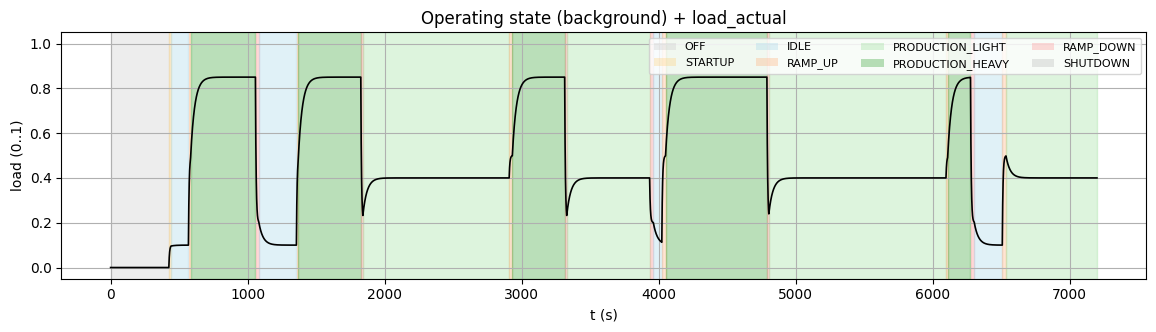

In [6]:
from matplotlib.patches import Patch

STATE_COLORS = {
    "OFF":              "#cccccc",
    "STARTUP":          "#ffd27f",
    "IDLE":             "#a8d8ea",
    "RAMP_UP":          "#ffb37f",
    "PRODUCTION_LIGHT": "#9ee09e",
    "PRODUCTION_HEAVY": "#3aa539",
    "RAMP_DOWN":        "#ff9999",
    "SHUTDOWN":         "#bbbbbb",
}

def shade_states(ax, df: pd.DataFrame) -> None:
    df = df.reset_index(drop=True)
    s = df["state"].to_numpy()
    starts = [0]
    for i in range(1, len(df)):
        if s[i] != s[i-1]:
            starts.append(i)
    starts.append(len(df))
    for a, b in zip(starts[:-1], starts[1:]):
        ax.axvspan(df["t_s"].iat[a], df["t_s"].iat[b-1],
                   color=STATE_COLORS.get(s[a], "#ffffff"), alpha=0.35)

fig, ax = plt.subplots(figsize=(14, 3.2))
shade_states(ax, df)
ax.plot(df["t_s"], df["load"], color="black", lw=1.2, label="load_actual")
ax.set_xlabel("t (s)"); ax.set_ylabel("load (0..1)")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Operating state (background) + load_actual")
ax.legend(handles=[Patch(facecolor=c, alpha=0.35, label=s) for s, c in STATE_COLORS.items()],
          ncol=4, loc="upper right", fontsize=8)
plt.show()

### 5.2 All 8 sensors

One subplot per sensor, sharing the x-axis. State bands repeated for context.

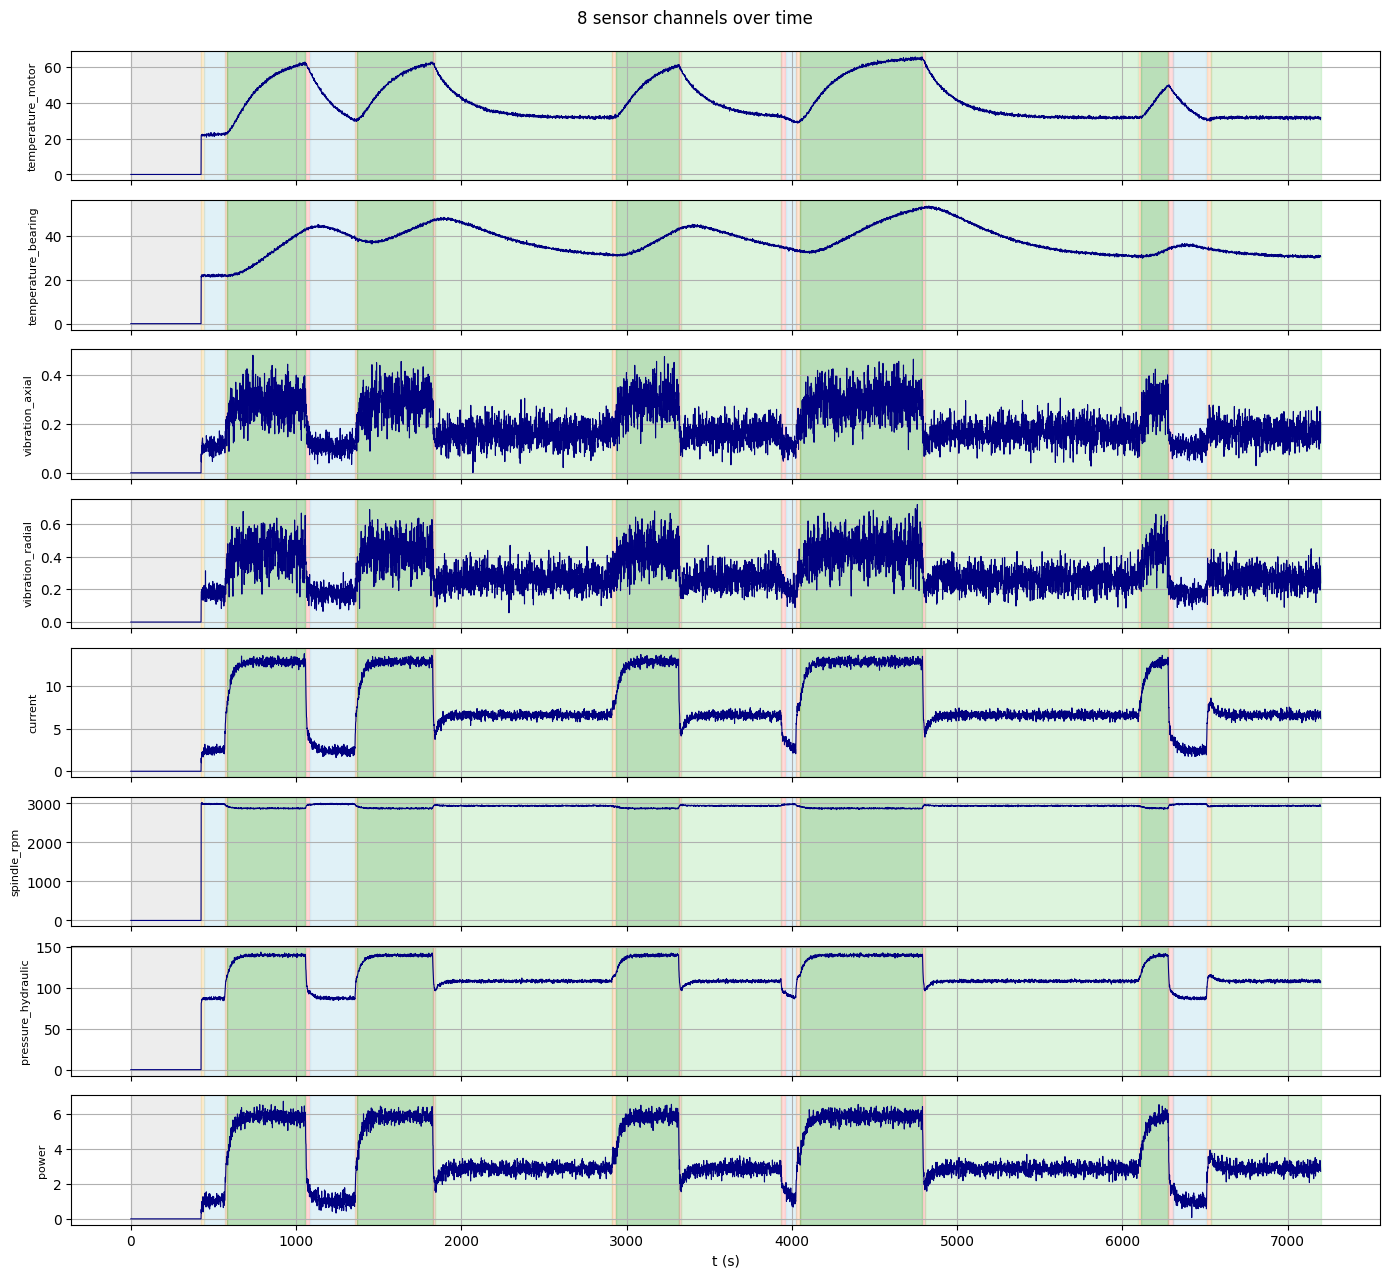

In [7]:
SENSORS = [
    "temperature_motor", "temperature_bearing",
    "vibration_axial",   "vibration_radial",
    "current",           "spindle_rpm",
    "pressure_hydraulic","power",
]

fig, axes = plt.subplots(len(SENSORS), 1, figsize=(14, 1.6 * len(SENSORS)),
                         sharex=True)
for ax, sensor in zip(axes, SENSORS):
    shade_states(ax, df)
    ax.plot(df["t_s"], df[sensor], lw=0.8, color="navy")
    ax.set_ylabel(sensor, fontsize=8)
axes[-1].set_xlabel("t (s)")
fig.suptitle("8 sensor channels over time", y=0.995)
plt.tight_layout()
plt.show()

### 5.3 Pairwise consistency

These scatter plots verify the physical couplings. We exclude `OFF` samples to keep the plots readable.

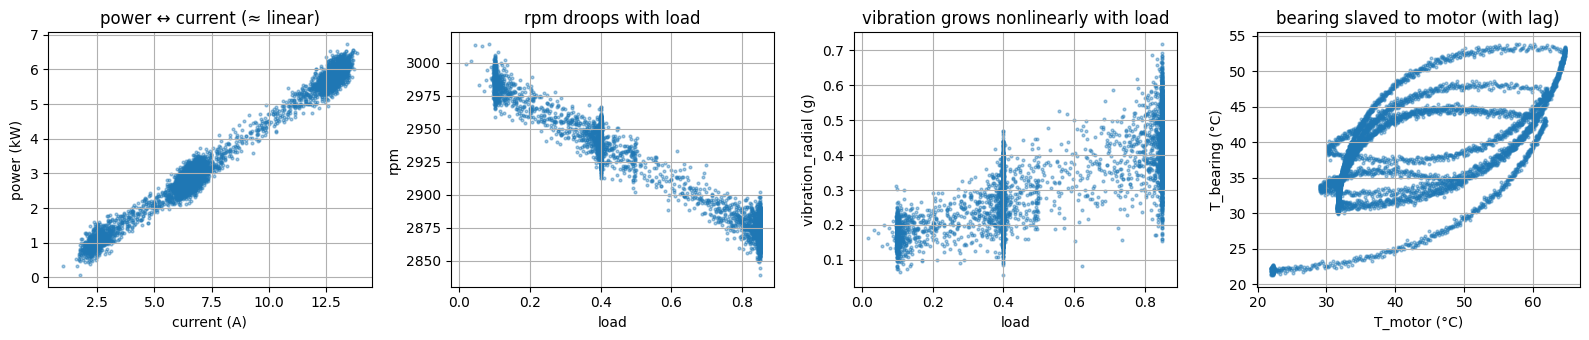

In [10]:
on = df[df["state"] != "OFF"]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
axes[0].scatter(on["current"], on["power"], s=4, alpha=0.4)
axes[0].set_xlabel("current (A)"); axes[0].set_ylabel("power (kW)")
axes[0].set_title("power ↔ current (≈ linear)")

axes[1].scatter(on["load"], on["spindle_rpm"], s=4, alpha=0.4)
axes[1].set_xlabel("load"); axes[1].set_ylabel("rpm")
axes[1].set_title("rpm droops with load")

axes[2].scatter(on["load"], on["vibration_radial"], s=4, alpha=0.4)
axes[2].set_xlabel("load"); axes[2].set_ylabel("vibration_radial (g)")
axes[2].set_title("vibration grows nonlinearly with load")

axes[3].scatter(on["T_motor_phys"], on["temperature_bearing"], s=4, alpha=0.4)
axes[3].set_xlabel("T_motor (°C)"); axes[3].set_ylabel("T_bearing (°C)")
axes[3].set_title("bearing slaved to motor (with lag)")

plt.tight_layout()
plt.show()

### 5.4 State-occupancy histogram

How much time the machine spent in each state. Useful to tune dwell distributions and transition weights.

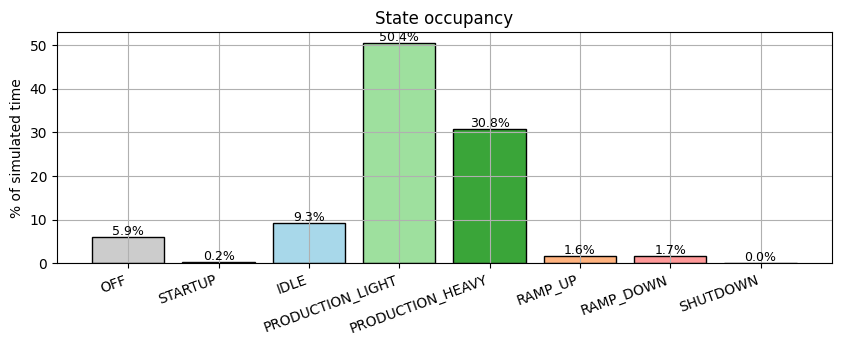

In [11]:
occ = (df["state"].value_counts(normalize=True) * 100).reindex(
    [s.value for s in State], fill_value=0.0
)
fig, ax = plt.subplots(figsize=(10, 3))
colors = [STATE_COLORS[s] for s in occ.index]
ax.bar(occ.index, occ.values, color=colors, edgecolor="black")
ax.set_ylabel("% of simulated time")
ax.set_title("State occupancy")
for i, v in enumerate(occ.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.show()

## 6. Iteration playground

Tweak coefficients, re-run, re-plot. Re-run cell 4 to regenerate `df` after changing any constant in cell 3.

Things to play with:

- `STATE_SPECS[...].dwell_s` → how often regimes alternate.
- `Machine.tau_load_steady` → how stiff steady-state load is.
- `Machine.tau_T_motor` / `tau_T_bearing` → thermal inertia.
- `k_current_b`, `k_power_factor`, `k_vib_*` → sensor sensitivity.
- `Machine.k_rpm_droop` → how much spindle slows under load.

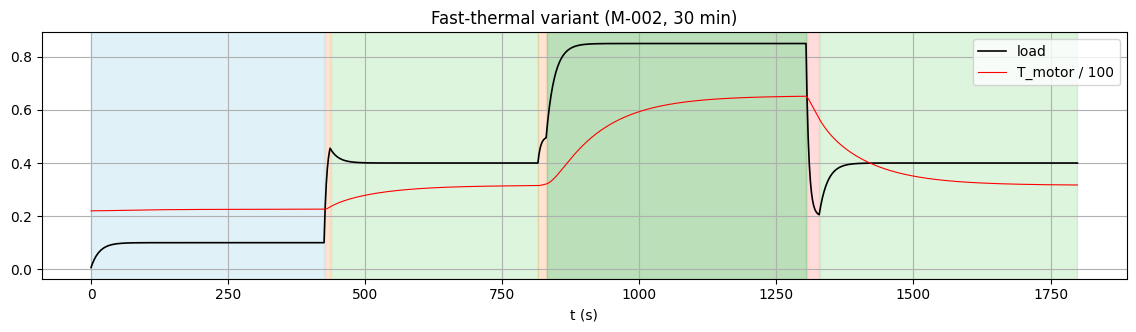

In [12]:
# Example: faster thermal response, less stiff load — see more dynamics in 30 min
random.seed(RNG_SEED); np.random.seed(RNG_SEED)
m2 = Machine(machine_id="M-002", state=State.IDLE)
m2.tau_T_motor = 90.0
m2.tau_load_steady = 15.0
df2 = simulate(m2, duration_s=30 * 60, dt=1.0)

fig, ax = plt.subplots(figsize=(14, 3.2))
shade_states(ax, df2)
ax.plot(df2["t_s"], df2["load"], color="black", lw=1.2, label="load")
ax.plot(df2["t_s"], df2["T_motor_phys"] / 100, color="red",  lw=0.8, label="T_motor / 100")
ax.set_xlabel("t (s)"); ax.legend(loc="upper right")
ax.set_title("Fast-thermal variant (M-002, 30 min)")
plt.show()

## 7. Export training dataset

We need a **persisted, version-controlled dataset** to iterate on model
architectures offline (no Fabric round-trip per experiment). Once a
model wins on this snapshot we'll re-train it inside Fabric reading the
same schema from the KQL Eventhouse.

### Format choice

| Layout | File | Why |
|---|---|---|
| **Long (events)** | `data/training/raw_telemetry.parquet` | Mirrors what arrives in the KQL `raw_telemetry` table from Eventstream. One row per `(ts, machineId, sensorId)`. |
| **Wide (per-timestamp)** | `data/training/telemetry_wide.parquet` | Mirrors the post-pivot KQL view that feeds the model. One row per `(ts, machineId)`, one column per sensor + the ground-truth `state` and `load`. |
| **CSV head sample** | `data/training/sample_head.csv` | Small, human-readable, diff-friendly in PRs. |

**Parquet** is the right primary format because:

- it's the storage format under OneLake / Delta Lake (what Fabric uses),
- columnar + snappy compression keeps the file ~10-20x smaller than CSV,
- it preserves dtypes (timestamps, floats, categoricals),
- `pandas` / `polars` / `pyspark` all read it natively.

Schema mirrors the live KQL `raw_telemetry` table fields:
`{machineId, sensorId, ts, value, quality}`. We add a `state` column on
the wide view as **ground-truth label** for evaluation (in production
the state will come from a Fabric KQL `machine_state` materialized
view - see `.copilot/PLAN.md` Phase 2).


### 7.1 Generate the dataset

Default config: **3 machines x 4 hours @ 1 Hz**. That gives ~14 k wide
rows and ~115 k long rows - small enough to commit (~3-5 MB total
parquet), large enough to train a windowed AE with meaningful
state-transition variety.


In [ ]:
from datetime import datetime, timezone
from pathlib import Path

DATASET_DIR = Path("../data/training").resolve()
DATASET_DIR.mkdir(parents=True, exist_ok=True)

# Tunable: how big a snapshot we want to commit.
# 5 machines x 24 h @ 1 Hz -> 432 k wide rows / 3.5 M long rows.
# Enough for train/val/test split, multiple FSM cycles per machine
# (so STARTUP/SHUTDOWN/RAMP transients are properly represented),
# and a touch of fleet variety.
N_MACHINES   = 5
DURATION_S   = 24 * 3600   # 24 hours
DT_S         = 1.0         # 1 Hz, matching live telemetry rate
START_TS_UTC = datetime(2026, 5, 15, 8, 0, 0, tzinfo=timezone.utc)

print(f"Will simulate {N_MACHINES} machines x {DURATION_S/3600:.1f} h "
      f"@ {1/DT_S:.0f} Hz -> "
      f"{N_MACHINES * int(DURATION_S/DT_S)} wide rows, "
      f"{N_MACHINES * int(DURATION_S/DT_S) * len(SENSORS)} long rows")
# Print only repo-relative path to avoid leaking the absolute working dir
# into committed notebook outputs.
print("Output dir: data/training/")

Will simulate 5 machines x 24.0 h @ 1 Hz -> 432000 wide rows, 3456000 long rows
Output dir: C:\Users\faustopalma\OneDrive - Microsoft\Documents\Customers\Other\Iveco\anomalydetection\data\training


In [13]:
def build_dataset(
    n_machines: int,
    duration_s: float,
    dt: float,
    start_ts: datetime,
    seed_base: int = RNG_SEED,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Run the simulator for N machines and return (long, wide) frames.

    Each machine gets its own RNG seed so the runs are deterministic
    but independent.
    """
    wide_frames: list[pd.DataFrame] = []
    long_frames: list[pd.DataFrame] = []

    for i in range(n_machines):
        machine_id = f"M-{i+1:03d}"
        random.seed(seed_base + i)
        np.random.seed(seed_base + i)

        machine = Machine(machine_id=machine_id, state=State.OFF)
        df_run = simulate(machine, duration_s=duration_s, dt=dt)

        ts = pd.to_datetime(start_ts) + pd.to_timedelta(df_run["t_s"], unit="s")

        wide = pd.DataFrame({
            "ts":         ts,
            "machineId":  machine_id,
            "state":      df_run["state"].astype("category"),
            "load":       df_run["load"].astype("float32"),
            **{s: df_run[s].astype("float32") for s in SENSORS},
        })
        wide_frames.append(wide)

        # Melt to event rows {machineId, sensorId, ts, value, quality}
        long = wide.melt(
            id_vars=["ts", "machineId"],
            value_vars=SENSORS,
            var_name="sensorId",
            value_name="value",
        )
        long["quality"] = np.float32(1.0)
        long = long.merge(
            wide[["ts", "machineId", "state"]], on=["ts", "machineId"], how="left"
        )
        long.loc[long["state"] == "OFF", "quality"] = np.float32(0.0)
        long = long.drop(columns=["state"])
        long = long[["machineId", "sensorId", "ts", "value", "quality"]]
        long_frames.append(long)

    long_df = pd.concat(long_frames, ignore_index=True)
    wide_df = pd.concat(wide_frames, ignore_index=True)
    return long_df, wide_df


long_df, wide_df = build_dataset(
    n_machines=N_MACHINES,
    duration_s=DURATION_S,
    dt=DT_S,
    start_ts=START_TS_UTC,
)
print("long shape:", long_df.shape, " | wide shape:", wide_df.shape)
print()
print("WIDE head:")
display(wide_df.head())
print("LONG head:")
display(long_df.head())


long shape: (3456000, 5)  | wide shape: (432000, 12)

WIDE head:


,ts,machineId,state,load,temperature_motor,temperature_bearing,vibration_axial,vibration_radial,current,spindle_rpm,pressure_hydraulic,power
0,2026-05-15 08:00:00+00:00,M-001,OFF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2026-05-15 08:00:01+00:00,M-001,OFF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2026-05-15 08:00:02+00:00,M-001,OFF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2026-05-15 08:00:03+00:00,M-001,OFF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2026-05-15 08:00:04+00:00,M-001,OFF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


LONG head:


,machineId,sensorId,ts,value,quality
0,M-001,temperature_motor,2026-05-15 08:00:00+00:00,0.0,0.0
1,M-001,temperature_motor,2026-05-15 08:00:01+00:00,0.0,0.0
2,M-001,temperature_motor,2026-05-15 08:00:02+00:00,0.0,0.0
3,M-001,temperature_motor,2026-05-15 08:00:03+00:00,0.0,0.0
4,M-001,temperature_motor,2026-05-15 08:00:04+00:00,0.0,0.0


### 7.2 Persist to disk (Parquet + CSV sample)

Parquet is written with **zstd** compression (better ratio than snappy
on float32 telemetry, native support in Spark/Fabric) and a row-group
size of 50 000. The CSV sample is the first 200 rows of the wide table
so reviewers can `cat` it in a PR.

In [17]:
LONG_PATH   = DATASET_DIR / "raw_telemetry.parquet"
WIDE_PATH   = DATASET_DIR / "telemetry_wide.parquet"
SAMPLE_PATH = DATASET_DIR / "sample_head.csv"

# zstd level 9 gives a strong size win over snappy/default-zstd on this
# float32 telemetry. Decoding cost is unchanged; only the one-shot write
# pays a small CPU price. Result: ~25 MB long + ~13 MB wide, well under
# git's 50 MB soft warning.
PARQUET_KW = dict(
    engine="pyarrow",
    compression="zstd",
    compression_level=9,
    row_group_size=50_000,
    index=False,
)

long_df.to_parquet(LONG_PATH, **PARQUET_KW)
wide_df.to_parquet(WIDE_PATH, **PARQUET_KW)
wide_df.head(200).to_csv(SAMPLE_PATH, index=False)

for p in (LONG_PATH, WIDE_PATH, SAMPLE_PATH):
    size_mb = p.stat().st_size / (1024 * 1024)
    print(f"{p.name:30s}  {size_mb:>8.2f} MB")

raw_telemetry.parquet              32.30 MB
telemetry_wide.parquet             19.67 MB
sample_head.csv                     0.01 MB


### 7.3 Reload + sanity check

Read the files back from disk and verify schema, ranges, and per-machine
state coverage.


In [15]:
wide_back = pd.read_parquet(WIDE_PATH)
long_back = pd.read_parquet(LONG_PATH)

print("=== WIDE schema ===")
print(wide_back.dtypes.to_string())
print()
print("=== LONG schema ===")
print(long_back.dtypes.to_string())
print()
print("=== Per-machine row counts (wide) ===")
print(wide_back.groupby("machineId").size().to_string())
print()
print("=== Per-machine state occupancy (% of time) ===")
occ = (wide_back.groupby("machineId", observed=True)["state"]
       .value_counts(normalize=True)
       .unstack(fill_value=0.0)
       .round(3) * 100)
display(occ)
print()
print("=== Sensor stats (wide, ON-state only) ===")
on_mask = wide_back["state"] != "OFF"
display(wide_back.loc[on_mask, SENSORS].describe().T[["min", "mean", "max", "std"]])


=== WIDE schema ===
ts                     datetime64[us, UTC]
machineId                              str
state                             category
load                               float32
temperature_motor                  float32
temperature_bearing                float32
vibration_axial                    float32
vibration_radial                   float32
current                            float32
spindle_rpm                        float32
pressure_hydraulic                 float32
power                              float32

=== LONG schema ===
machineId                    str
sensorId                     str
ts           datetime64[us, UTC]
value                    float32
quality                  float32

=== Per-machine row counts (wide) ===
machineId
M-001    86400
M-002    86400
M-003    86400
M-004    86400
M-005    86400

=== Per-machine state occupancy (% of time) ===


state,IDLE,OFF,PRODUCTION_HEAVY,PRODUCTION_LIGHT,RAMP_DOWN,RAMP_UP,SHUTDOWN,STARTUP
machineId,,,,,,,,
M-001,11.4,3.4,18.9,63.0,1.4,1.4,0.3,0.2
M-002,14.3,3.7,26.8,51.1,1.9,1.8,0.3,0.2
M-003,12.1,2.1,28.0,54.6,1.5,1.4,0.2,0.2
M-004,16.6,4.7,25.5,49.3,1.5,1.8,0.3,0.3
M-005,10.5,2.0,28.4,55.8,1.5,1.5,0.1,0.1



=== Sensor stats (wide, ON-state only) ===


,min,mean,max,std
temperature_motor,20.715160,38.718197,66.849136,12.585089
temperature_bearing,21.072014,36.001484,59.859703,8.912878
vibration_axial,0.000000,0.188999,0.560761,0.078531
vibration_radial,0.000000,0.296716,0.808304,0.109183
current,0.198709,7.608788,14.312063,3.372804
spindle_rpm,2835.363037,2929.191162,3026.128174,36.877857
pressure_hydraulic,77.281113,113.045517,143.714844,16.828548
power,0.000000,3.380428,6.988546,1.587461


### 7.4 What downstream notebooks will load

A future training notebook (e.g. `notebooks/07_train_offline.ipynb`)
will start with:

```python
import pandas as pd
df = pd.read_parquet("../data/training/telemetry_wide.parquet")
on = df[df["state"] != "OFF"].sort_values(["machineId", "ts"])
```

When we move training into Fabric, the same notebook becomes:

```python
df = spark.read.kusto(cluster_uri, "kql_telemetry", query="""
    raw_telemetry
    | where ts between (datetime(2026-05-15) .. datetime(2026-05-15 12:00))
    | summarize value=avg(value) by ts=bin(ts, 1s), machineId, sensorId
    | evaluate pivot(sensorId, any(value))
""").toPandas()
```

Same columns, same dtypes, same code path for the model.


## 8. Eval dataset with injected anomalies

The dataset under `data/training/` is **clean by design** — it is the
"normal" distribution the autoencoder will be trained on. To measure
whether the trained model actually catches degraded equipment, we now
build a **separate evaluation snapshot** that mirrors the same schema
but contains controlled anomalies with ground-truth labels.

### Train / eval separation

| Snapshot | Machines | Seed base | Contents | Used for |
|---|---|---|---|---|
| `data/training/` | M-001..M-005 | `RNG_SEED` | clean | model `fit()` |
| `data/eval/` | **M-101..M-105** | **`RNG_SEED + 1000`** | clean baseline + injected faults + labels | scoring + threshold tuning + final report |

The eval machines use a **different seed base** so that the noise
realisations are independent — no information leak from training.
2 of the 5 eval machines stay healthy as a control group; the other 3
each carry a single fault family.

### Fault catalog (3 families)

| Family | Affected sensors | Pattern | Realism notes |
|---|---|---|---|
| **bearing** | `vibration_radial` ↑↑, `vibration_axial` ↑, `temperature_bearing` ↑, `current` ↑, `power` ↑ | slow ramp + growing impulsive spikes, scaled by load | Classic spalling/pitting signature; multivariate, evolves over hours. |
| **hydraulic_leak** | `pressure_hydraulic` ↓ (ramp) or oscillating | monotonic drop *or* low-freq oscillation as pump cycles | Mono-sensor, subtle — stress-tests the model's univariate sensitivity. |
| **sensor_stuck** | one selected sensor frozen at a constant value | step (instant freeze) with `quality=0` flag | A *data* anomaly, not a *machine* anomaly — useful negative class so we can later teach the pipeline to suppress these alerts. |

All faults activate **only when the machine is running** (load > 0): a
broken bearing doesn't vibrate while the motor is OFF. Sensor freezes
are the exception — they apply throughout the chosen window.

### Episode budget

5 machines × 24 h gives plenty of room. Per faulty machine we schedule
**4 episodes** of varied severity (some obvious, some subdued) so each
family has 4 events for metric computation.


### 8.1 Build the clean eval baseline

Same simulator, different machine ids and seeds. We reuse the
`build_dataset` function from Section 7.


In [18]:
EVAL_DATASET_DIR = Path("../data/eval").resolve()
EVAL_DATASET_DIR.mkdir(parents=True, exist_ok=True)

EVAL_N_MACHINES   = 5
EVAL_DURATION_S   = 24 * 3600
EVAL_DT_S         = 1.0
EVAL_START_TS_UTC = datetime(2026, 5, 16, 8, 0, 0, tzinfo=timezone.utc)
EVAL_SEED_BASE    = RNG_SEED + 1000   # decouple from training noise

# Build with the same function but with a different seed base and a
# machine-id offset so eval ids are M-101..M-105.
def _build_eval_clean() -> tuple[pd.DataFrame, pd.DataFrame]:
    long_frames, wide_frames = [], []
    for i in range(EVAL_N_MACHINES):
        machine_id = f"M-{100 + i + 1:03d}"   # M-101, M-102, ...
        random.seed(EVAL_SEED_BASE + i)
        np.random.seed(EVAL_SEED_BASE + i)

        machine = Machine(machine_id=machine_id, state=State.OFF)
        df_run = simulate(machine, duration_s=EVAL_DURATION_S, dt=EVAL_DT_S)

        ts = pd.to_datetime(EVAL_START_TS_UTC) + pd.to_timedelta(df_run["t_s"], unit="s")

        wide = pd.DataFrame({
            "ts":         ts,
            "machineId":  machine_id,
            "state":      df_run["state"].astype("category"),
            "load":       df_run["load"].astype("float32"),
            **{s: df_run[s].astype("float32") for s in SENSORS},
        })
        wide_frames.append(wide)

        long = wide.melt(
            id_vars=["ts", "machineId"], value_vars=SENSORS,
            var_name="sensorId", value_name="value",
        )
        long["quality"] = np.float32(1.0)
        long = long.merge(wide[["ts", "machineId", "state"]],
                          on=["ts", "machineId"], how="left")
        long.loc[long["state"] == "OFF", "quality"] = np.float32(0.0)
        long = long.drop(columns=["state"])
        long = long[["machineId", "sensorId", "ts", "value", "quality"]]
        long_frames.append(long)

    return (pd.concat(long_frames, ignore_index=True),
            pd.concat(wide_frames, ignore_index=True))


eval_long_clean, eval_wide_clean = _build_eval_clean()
print("eval clean wide:", eval_wide_clean.shape,
      " | clean long:", eval_long_clean.shape)
print("machines:", sorted(eval_wide_clean['machineId'].unique()))


eval clean wide: (432000, 12)  | clean long: (3456000, 5)
machines: ['M-101', 'M-102', 'M-103', 'M-104', 'M-105']


### 8.2 Anomaly injectors

Each injector takes a *copy* of the wide DataFrame, restricts itself to
one machine and a `[onset_ts, onset_ts + duration_s]` window, and
modifies the relevant sensors in place. They all return the modified
frame plus a per-row boolean mask for the affected window so we can
rebuild ground-truth labels.

A few design choices worth flagging:

- **Load-scaling**: machine faults (bearing, hydraulic) scale with
  `wide['load']` so anomalies are essentially silent during OFF/IDLE
  and most visible during PRODUCTION_HEAVY. Realistic and forces the
  model to handle state-dependent baselines.
- **Severity ramp**: `severity_max` is reached linearly across the
  window. The very first samples after onset are barely visible — this
  is what gives a meaningful *lead-time* metric later.
- **Spikes**: bearing fault adds Poisson-timed impulse spikes on
  `vibration_radial` whose amplitude grows with severity, mimicking
  the impact-style signature of pitted rolling elements (we cannot
  resolve true BPFO/BPFI tones at 1 Hz, so we proxy with random
  impulses).


In [27]:
from dataclasses import dataclass
from typing import Literal


@dataclass(frozen=True)
class FaultSpec:
    """A scheduled anomaly episode."""
    fault_type: Literal["bearing", "hydraulic_leak", "sensor_stuck"]
    machine_id: str
    onset_ts: datetime
    duration_s: float
    severity_max: float = 1.0
    affected_sensor: str | None = None
    pattern: str = "ramp"
    notes: str = ""


def _window_mask(wide, machine_id, onset_ts, duration_s):
    end_ts = pd.to_datetime(onset_ts) + pd.to_timedelta(duration_s, unit="s")
    return ((wide["machineId"] == machine_id)
            & (wide["ts"] >= pd.to_datetime(onset_ts))
            & (wide["ts"] <  end_ts))


def _ramp(t_norm):
    return np.clip(t_norm, 0.0, 1.0).astype(np.float32)


def inject_bearing(wide, spec, rng):
    mask = _window_mask(wide, spec.machine_id, spec.onset_ts, spec.duration_s)
    if not mask.any():
        return mask

    ts_in = wide.loc[mask, "ts"]
    t0 = pd.to_datetime(spec.onset_ts)
    pos = ((ts_in - t0).dt.total_seconds() / spec.duration_s).to_numpy()
    sev = spec.severity_max * _ramp(pos)
    load = np.asarray(wide.loc[mask, "load"], dtype=np.float32)

    wide.loc[mask, "vibration_radial"]    = wide.loc[mask, "vibration_radial"].to_numpy(copy=True) + (sev * 0.40 * load)
    wide.loc[mask, "vibration_axial"]     = wide.loc[mask, "vibration_axial"].to_numpy(copy=True)  + (sev * 0.15 * load)
    wide.loc[mask, "temperature_bearing"] = wide.loc[mask, "temperature_bearing"].to_numpy(copy=True) + (sev * 7.0 * load)
    wide.loc[mask, "current"]             = wide.loc[mask, "current"].to_numpy(copy=True) + (sev * 0.60 * load)
    wide.loc[mask, "power"]               = wide.loc[mask, "power"].to_numpy(copy=True) + (sev * 0.25 * load)

    n = int(mask.sum())
    base_rate = 0.005
    spike_prob = base_rate * sev * load
    is_spike = rng.random(n) < spike_prob
    spike_amp = (0.6 + 0.4 * rng.random(n)) * sev * load
    spike_add = np.zeros(n, dtype=np.float32)
    spike_add[is_spike] = spike_amp[is_spike].astype(np.float32)
    wide.loc[mask, "vibration_radial"] = (
        wide.loc[mask, "vibration_radial"].to_numpy(copy=True) + spike_add
    )
    return mask


def inject_hydraulic_leak(wide, spec, rng):
    mask = _window_mask(wide, spec.machine_id, spec.onset_ts, spec.duration_s)
    if not mask.any():
        return mask

    ts_in = wide.loc[mask, "ts"]
    t0 = pd.to_datetime(spec.onset_ts)
    pos = ((ts_in - t0).dt.total_seconds() / spec.duration_s).to_numpy()
    sev = spec.severity_max * _ramp(pos)
    load = np.asarray(wide.loc[mask, "load"], dtype=np.float32)
    pressure = np.asarray(wide.loc[mask, "pressure_hydraulic"], dtype=np.float32).copy()

    if spec.pattern == "oscillation":
        secs = (ts_in - t0).dt.total_seconds().to_numpy()
        osc = np.sin(2 * np.pi * secs / 60.0).astype(np.float32)
        pressure = pressure + (sev * 18.0 * osc * load)
    else:
        pressure = pressure * (1.0 - sev * 0.45 * load)

    wide.loc[mask, "pressure_hydraulic"] = pressure.astype(np.float32)
    wide.loc[mask, "power"] = (
        wide.loc[mask, "power"].to_numpy(copy=True) + (sev * 0.15 * load).astype(np.float32)
    )
    return mask


def inject_sensor_stuck(wide, spec, rng):
    if spec.affected_sensor is None:
        raise ValueError("sensor_stuck requires affected_sensor")
    mask = _window_mask(wide, spec.machine_id, spec.onset_ts, spec.duration_s)
    if not mask.any():
        return mask

    pre = wide[(wide["machineId"] == spec.machine_id)
               & (wide["ts"] < pd.to_datetime(spec.onset_ts))]
    if len(pre) > 0:
        stuck_val = float(pre.iloc[-1][spec.affected_sensor])
    else:
        stuck_val = float(wide.loc[mask, spec.affected_sensor].iloc[0])

    wide.loc[mask, spec.affected_sensor] = np.float32(stuck_val)
    return mask


INJECTORS = {
    "bearing":         inject_bearing,
    "hydraulic_leak":  inject_hydraulic_leak,
    "sensor_stuck":    inject_sensor_stuck,
}

print("Injectors registered:", list(INJECTORS))

Injectors registered: ['bearing', 'hydraulic_leak', 'sensor_stuck']


### 8.3 Episode catalog and apply

Three faulty machines, four episodes each. Severity, sensor, onset and
duration vary so the eval covers a realistic spread.


In [28]:
def _ts(hours: float) -> datetime:
    """Helper: hours after EVAL_START_TS_UTC."""
    return EVAL_START_TS_UTC + pd.to_timedelta(hours, unit="h")


EPISODES: list[FaultSpec] = [
    # --- M-103: bearing degradation, 4 episodes of growing severity ---
    FaultSpec("bearing",        "M-103", _ts(2.0),  duration_s=1.5*3600,
              severity_max=0.30, notes="early-stage, subdued"),
    FaultSpec("bearing",        "M-103", _ts(7.0),  duration_s=2.0*3600,
              severity_max=0.55, notes="mid-stage"),
    FaultSpec("bearing",        "M-103", _ts(13.0), duration_s=2.5*3600,
              severity_max=0.80, notes="advanced"),
    FaultSpec("bearing",        "M-103", _ts(19.5), duration_s=3.0*3600,
              severity_max=1.00, notes="late-stage, near failure"),

    # --- M-104: hydraulic leak, mix of ramp and oscillation patterns ---
    FaultSpec("hydraulic_leak", "M-104", _ts(3.0),  duration_s=2.0*3600,
              severity_max=0.40, pattern="ramp",
              notes="slow leak, mild"),
    FaultSpec("hydraulic_leak", "M-104", _ts(8.5),  duration_s=1.0*3600,
              severity_max=0.70, pattern="oscillation",
              notes="pump cycling"),
    FaultSpec("hydraulic_leak", "M-104", _ts(14.0), duration_s=2.5*3600,
              severity_max=0.85, pattern="ramp",
              notes="severe leak"),
    FaultSpec("hydraulic_leak", "M-104", _ts(20.0), duration_s=2.0*3600,
              severity_max=1.00, pattern="oscillation",
              notes="failing pump"),

    # --- M-105: sensor stuck, different sensors and durations ---
    FaultSpec("sensor_stuck",   "M-105", _ts(2.5),  duration_s=0.5*3600,
              affected_sensor="temperature_motor",
              notes="short freeze"),
    FaultSpec("sensor_stuck",   "M-105", _ts(7.0),  duration_s=1.5*3600,
              affected_sensor="pressure_hydraulic",
              notes="medium freeze"),
    FaultSpec("sensor_stuck",   "M-105", _ts(12.0), duration_s=2.0*3600,
              affected_sensor="vibration_radial",
              notes="long freeze on key sensor"),
    FaultSpec("sensor_stuck",   "M-105", _ts(18.0), duration_s=3.0*3600,
              affected_sensor="current",
              notes="long freeze, electrical"),
]

# Apply episodes on a copy of the clean baseline
eval_wide = eval_wide_clean.copy()
eval_wide["fault_type"] = pd.Series(
    pd.Categorical(["normal"] * len(eval_wide),
                   categories=["normal", "bearing", "hydraulic_leak", "sensor_stuck"]))
eval_wide["is_anomaly"] = False
# Ensure category dtype can store new values
eval_wide["fault_type"] = eval_wide["fault_type"].astype(
    pd.CategoricalDtype(categories=["normal", "bearing", "hydraulic_leak", "sensor_stuck"]))

inj_rng = np.random.default_rng(EVAL_SEED_BASE + 9999)

for spec in EPISODES:
    fn = INJECTORS[spec.fault_type]
    mask = fn(eval_wide, spec, inj_rng)
    eval_wide.loc[mask, "is_anomaly"] = True
    eval_wide.loc[mask, "fault_type"] = spec.fault_type

# Episode-level labels DataFrame (one row per scheduled fault)
eval_labels = pd.DataFrame([{
    "machineId":       s.machine_id,
    "fault_type":      s.fault_type,
    "affected_sensor": s.affected_sensor,
    "onset_ts":        pd.to_datetime(s.onset_ts),
    "end_ts":          pd.to_datetime(s.onset_ts) + pd.to_timedelta(s.duration_s, unit="s"),
    "duration_s":      float(s.duration_s),
    "severity_max":    float(s.severity_max),
    "pattern":         s.pattern,
    "notes":           s.notes,
} for s in EPISODES])

print(f"Applied {len(EPISODES)} episodes")
print(f"Anomalous samples: {int(eval_wide['is_anomaly'].sum()):,} "
      f"/ {len(eval_wide):,} "
      f"({100 * eval_wide['is_anomaly'].mean():.2f}%)")
print()
print("Per-machine breakdown:")
display(eval_wide.groupby("machineId", observed=True)["fault_type"]
        .value_counts(normalize=False).unstack(fill_value=0))
print()
display(eval_labels)


Applied 12 episodes
Anomalous samples: 84,600 / 432,000 (19.58%)

Per-machine breakdown:


fault_type,normal,bearing,hydraulic_leak,sensor_stuck
machineId,,,,
M-101,86400,0,0,0
M-102,86400,0,0,0
M-103,54000,32400,0,0
M-104,59400,0,27000,0
M-105,61200,0,0,25200


,machineId,fault_type,affected_sensor,onset_ts,end_ts,duration_s,severity_max,pattern,notes
0,M-103,bearing,NaN,2026-05-16 10:00:00+00:00,2026-05-16 11:30:00+00:00,5400.0,0.30,ramp,"early-stage, subdued"
1,M-103,bearing,NaN,2026-05-16 15:00:00+00:00,2026-05-16 17:00:00+00:00,7200.0,0.55,ramp,mid-stage
2,M-103,bearing,NaN,2026-05-16 21:00:00+00:00,2026-05-16 23:30:00+00:00,9000.0,0.80,ramp,advanced
3,M-103,bearing,NaN,2026-05-17 03:30:00+00:00,2026-05-17 06:30:00+00:00,10800.0,1.00,ramp,"late-stage, near failure"
4,M-104,hydraulic_leak,NaN,2026-05-16 11:00:00+00:00,2026-05-16 13:00:00+00:00,7200.0,0.40,ramp,"slow leak, mild"
5,M-104,hydraulic_leak,NaN,2026-05-16 16:30:00+00:00,2026-05-16 17:30:00+00:00,3600.0,0.70,oscillation,pump cycling
6,M-104,hydraulic_leak,NaN,2026-05-16 22:00:00+00:00,2026-05-17 00:30:00+00:00,9000.0,0.85,ramp,severe leak
7,M-104,hydraulic_leak,NaN,2026-05-17 04:00:00+00:00,2026-05-17 06:00:00+00:00,7200.0,1.00,oscillation,failing pump
8,M-105,sensor_stuck,temperature_motor,2026-05-16 10:30:00+00:00,2026-05-16 11:00:00+00:00,1800.0,1.00,ramp,short freeze
9,M-105,sensor_stuck,pressure_hydraulic,2026-05-16 15:00:00+00:00,2026-05-16 16:30:00+00:00,5400.0,1.00,ramp,medium freeze


### 8.4 Persist eval files

Same parquet codec and row-group settings as the training snapshot.


In [ ]:
# Long-form (event-shaped) view, mirroring the live KQL schema.
# Drop quality=0 mark on stuck-sensor episodes to make the dropout
# visible to downstream consumers (this is what the live pipeline
# would see if a sensor stopped reporting).
eval_long = eval_wide.melt(
    id_vars=["ts", "machineId"],
    value_vars=SENSORS,
    var_name="sensorId",
    value_name="value",
)
eval_long["quality"] = np.float32(1.0)
# OFF samples: quality 0 (machine off, no real reading)
eval_long = eval_long.merge(
    eval_wide[["ts", "machineId", "state"]],
    on=["ts", "machineId"], how="left",
)
eval_long.loc[eval_long["state"] == "OFF", "quality"] = np.float32(0.0)
# Stuck-sensor episodes: quality 0 on the affected sensor only
for spec in EPISODES:
    if spec.fault_type != "sensor_stuck":
        continue
    end_ts = pd.to_datetime(spec.onset_ts) + pd.to_timedelta(spec.duration_s, unit="s")
    sel = ((eval_long["machineId"] == spec.machine_id)
           & (eval_long["sensorId"] == spec.affected_sensor)
           & (eval_long["ts"] >= pd.to_datetime(spec.onset_ts))
           & (eval_long["ts"] <  end_ts))
    eval_long.loc[sel, "quality"] = np.float32(0.0)
eval_long = eval_long.drop(columns=["state"])
eval_long = eval_long[["machineId", "sensorId", "ts", "value", "quality"]]

EVAL_LONG_PATH   = EVAL_DATASET_DIR / "raw_telemetry.parquet"
EVAL_WIDE_PATH   = EVAL_DATASET_DIR / "telemetry_wide.parquet"
EVAL_LABELS_PATH = EVAL_DATASET_DIR / "anomaly_labels.parquet"

eval_long.to_parquet(EVAL_LONG_PATH, **PARQUET_KW)
eval_wide.to_parquet(EVAL_WIDE_PATH, **PARQUET_KW)
eval_labels.to_parquet(EVAL_LABELS_PATH, engine='pyarrow',
                       compression='zstd', compression_level=9, index=False)

for p in (EVAL_LONG_PATH, EVAL_WIDE_PATH, EVAL_LABELS_PATH):
    size_mb = p.stat().st_size / (1024 * 1024)
    print(f"{p.name:30s}  {size_mb:>8.2f} MB")


### 8.5 Visual sanity check

For each fault family pick one episode and overlay the relevant
sensor(s) before/after injection. The shaded band marks the labelled
anomaly window.


In [ ]:
def _plot_episode(spec: FaultSpec, sensors_to_show: list[str],
                  pad_h: float = 1.5):
    """Plot the chosen sensors around an episode, with the window shaded."""
    pad = pd.to_timedelta(pad_h, unit="h")
    t0 = pd.to_datetime(spec.onset_ts) - pad
    t1 = pd.to_datetime(spec.onset_ts) + pd.to_timedelta(spec.duration_s, unit="s") + pad

    sub_clean = eval_wide_clean[(eval_wide_clean["machineId"] == spec.machine_id)
                                & (eval_wide_clean["ts"].between(t0, t1))]
    sub_anom  = eval_wide[(eval_wide["machineId"] == spec.machine_id)
                          & (eval_wide["ts"].between(t0, t1))]

    fig, axes = plt.subplots(len(sensors_to_show), 1,
                             figsize=(13, 1.8 * len(sensors_to_show)),
                             sharex=True)
    if len(sensors_to_show) == 1:
        axes = [axes]
    for ax, sensor in zip(axes, sensors_to_show):
        ax.plot(sub_clean["ts"], sub_clean[sensor],
                lw=0.7, color="tab:gray", alpha=0.7, label="clean")
        ax.plot(sub_anom["ts"],  sub_anom[sensor],
                lw=0.8, color="tab:red", label="with anomaly")
        ax.axvspan(pd.to_datetime(spec.onset_ts),
                   pd.to_datetime(spec.onset_ts) + pd.to_timedelta(spec.duration_s, unit="s"),
                   color="orange", alpha=0.15, label="labelled window")
        ax.set_ylabel(sensor, fontsize=8)
        ax.legend(loc="upper left", fontsize=7)
    axes[0].set_title(f"{spec.fault_type} on {spec.machine_id} "
                      f"(severity_max={spec.severity_max}, "
                      f"pattern={spec.pattern})", fontsize=10)
    axes[-1].set_xlabel("time")
    plt.tight_layout()
    plt.show()


# Pick one episode per family
ep_bearing    = next(s for s in EPISODES if s.fault_type == "bearing"
                                            and s.severity_max >= 0.7)
ep_hydraulic  = next(s for s in EPISODES if s.fault_type == "hydraulic_leak"
                                            and s.pattern == "ramp"
                                            and s.severity_max >= 0.7)
ep_stuck      = next(s for s in EPISODES if s.fault_type == "sensor_stuck"
                                            and s.duration_s >= 1.5*3600)

_plot_episode(ep_bearing,
              ["vibration_radial", "vibration_axial",
               "temperature_bearing", "current"])
_plot_episode(ep_hydraulic,
              ["pressure_hydraulic", "power"])
_plot_episode(ep_stuck,
              [ep_stuck.affected_sensor])


### 8.6 What the training notebook will load

```python
import pandas as pd

# Training (clean) — for model.fit()
train = pd.read_parquet("../data/training/telemetry_wide.parquet")

# Evaluation (with anomalies) — for model.predict() and metrics
eval_df  = pd.read_parquet("../data/eval/telemetry_wide.parquet")
labels   = pd.read_parquet("../data/eval/anomaly_labels.parquet")

# Per-row ground truth is already on eval_df['is_anomaly']
# Per-episode metadata (severity, pattern, sensor) is on labels
```

In Fabric the equivalent eval comes from running the same injector on a
KQL snapshot of the live `raw_telemetry` table — same schema, same
labels DataFrame, no code change.
